# A reporter reference, from receipt to a protocol plan

A lab is preparing a **reporter reference for a later fluorescence study**. The intended construct is *pReference-Green*, and the intended recipient is *host H1*. The immediate request is two deposited samples from the resulting culture; fluorescence measurement and clone verification will happen later.

The project starts with an awkward detail: the vector arrived as **receipt R-042, lot V-17, in a bacterial stab**. The insert is already available as DNA. Someone must prepare vector DNA before a robot can use it.

We will follow that one received material through the files: **what arrived → what is planned → what the protocol specifies → what the robot would do**. At each point, we will open the relevant Turtle rather than treat it as an opaque export.

The study and records are illustrative. The dataset uses clearly marked dummy sequences and software-test method parameters, not a validated laboratory protocol. No robot is run in this notebook.


<details>
<summary><strong>Run this notebook</strong></summary>
<p>From the repository root, with Python 3.11 or 3.12:</p>
<pre>uv run --extra opentrons --extra star --with jupyterlab jupyter lab examples/cloning_provenance/cloning_provenance.ipynb</pre>
<p>Use the environment's Python kernel and run the cells in order. New artifacts go under the ignored <code>build/cloning-notebook/</code> directory. Saved outputs can be read without running anything.</p>
</details>

The [four input files](data/reporter_reference/README.md) are part of this example. Table formatting and Turtle selection live in [notebook_views.py](notebook_views.py), keeping the compiler calls visible here.


In [1]:
import notebook_views as view
from notebook_views import EX, LAB, LABOP, PROV, SBOL
from rdflib import RDF, Graph

import lab
from lab.experiments import cloning
from lab.inventory import Inventory
from lab.operations import Transfer
from lab.provenance import Component, Document, EvidenceState
from lab.targets import LiquidHandler

output = view.fresh_output()

## 1. What did the lab receive?

Start with the designs and the material records. The vector **design** and the received **lot** are different objects. The inventory then says where that lot is and in what form it is available. Storage positions are distinct from the robot deck addresses assigned later.


In [2]:
input_ttl = view.CASE / "designs-and-materials.ttl"
document = Document.read(input_ttl, namespace=str(EX).rstrip("/")).freeze()
inventory = Inventory.read(view.CASE / "inventory.json", document=document)

view.inventory(inventory, document)

Material record,Intended design,Form,Available,Location
Host aliquot H1-03,Host H1,competent_cells,20 µL,Cell box H1 / A1
Insert aliquot I-07,Green reporter cassette,dna,10 µL,DNA rack D1 / C2
Receipt R-042 / lot V-17,pReference backbone,bacterial_stab,1 unit,Receipt box / B3


**Read the corresponding Turtle.** A `.ttl` file is a text representation of an RDF graph: statements with a subject, a relationship, and an object. Prefixes abbreviate full identifiers. `ex:received_stab` is one persistent identity, not a Python variable or a file path.

The next cell selects real statements about the vector and its received material. It omits housekeeping fields and uses prefixes for readability; it does not change their meaning.


In [3]:
view.turtle(
    input_ttl,
    [str(EX.vector), str(EX.received_stab)],
    predicates=(RDF.type, SBOL.name, PROV.wasDerivedFrom, LAB.evidenceState),
)

@prefix prov: <http://www.w3.org/ns/prov#> .
@prefix ex: <https://example.org/reporter/> .
@prefix sbol: <http://sbols.org/v3#> .
@prefix lab: <https://the-lab-compiler.github.io/lab-py/ns#> .

ex:received_stab a sbol:Implementation ;
    sbol:name "Receipt R-042 / lot V-17" ;
    prov:wasDerivedFrom ex:vector ;
    lab:evidenceState lab:recorded .

ex:vector a sbol:Component ;
    sbol:name "pReference backbone" .

Read this as: **“Receipt R-042 is a material implementation associated with the pReference vector design.”**

- `a sbol:Component` declares a design; `a sbol:Implementation` declares a material realization or intended realization.
- `prov:wasDerivedFrom` links the material record to its intended design. It does not establish that the sequence was verified.
- `lab:evidenceState lab:recorded` says this is a supplied inventory assertion in our example.

A semicolon continues statements about the same subject; a period finishes that group. The storage position and the counted `bacterial_stab` form live in `inventory.json`. The TTL and inventory share the same implementation IRI.


## 2. What needs to happen before there are two samples?

We request the intended H1/reference material. Two samples here means **two deposits from one upstream culture**, not two independent clones.

The project supplies [routes](data/reporter_reference/system.json) and [method parameters](data/reporter_reference/methods.json) as separate inputs. One route explicitly converts a vector stab into vector DNA using external procedure **P01**. The planner may use that route; it may not silently treat the stab as pipettable DNA.


Order,Task,Expected material,Responsible system
1,Prepare vector DNA,dna: 10 µL,External procedure P01
2,Assemble reporter design,dna: 5 µL,Liquid handler
3,Introduce it into host H1,culture: 5 µL,Liquid handler
4,Deposit a sample,plated_sample: 1 sample,Liquid handler
5,Deposit a sample,plated_sample: 1 sample,Liquid handler


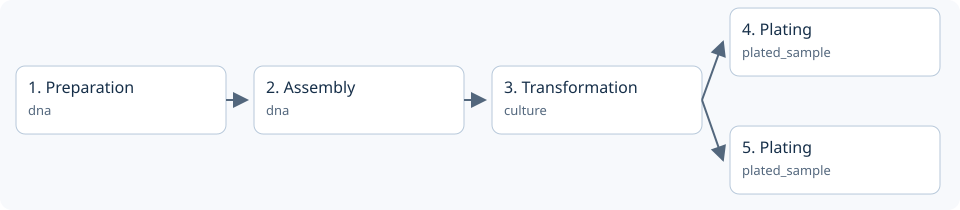

In [4]:
strain = document.get(str(EX.strain), Component)
request = cloning.BuildRequest(
    identity=str(EX.build),
    targets=(cloning.CountTarget(design=strain.ref, count=2),),
)
plan = cloning.plan(
    request,
    document=document,
    inventory=inventory,
    system=cloning.CloningSystem.read(view.CASE / "system.json"),
    methods=cloning.CloningMethods.read(view.CASE / "methods.json"),
)
plan.require_ready()
view.plan(plan)

The first stage is manual preparation; the remaining stages can be compiled for a liquid handler. Both deposits share the culture produced by the transformation stage. These are material dependencies; the protocol specifies an ordered stage list.

**What did planning add to the SBOL graph?** Follow the new vector-DNA output back to its preparation activity, then through the activity's `Usage` to receipt R-042.


In [5]:
preparation = plan.tasks[0]
planning_ttl = plan.document.write(output / "build-provenance.ttl")
view.turtle(
    planning_ttl,
    [preparation.output.identity, preparation.identity],
    predicates=(
        RDF.type,
        PROV.wasDerivedFrom,
        PROV.wasGeneratedBy,
        PROV.qualifiedUsage,
        PROV.entity,
        LAB.evidenceState,
    ),
    follow=(PROV.qualifiedUsage,),
    prefixes={"build": request.identity + "/", "prep": preparation.identity + "/"},
)

@prefix prov: <http://www.w3.org/ns/prov#> .
@prefix ex: <https://example.org/reporter/> .
@prefix sbol: <http://sbols.org/v3#> .
@prefix lab: <https://the-lab-compiler.github.io/lab-py/ns#> .
@prefix build: <https://example.org/reporter/build/> .
@prefix prep: <https://example.org/reporter/build/preparation_1_6a0c3b428b5f/> .

build:preparation_1_6a0c3b428b5f a prov:Activity ;
    prov:qualifiedUsage prep:Usage1 ;
    lab:evidenceState lab:planned .

prep:Usage1 a prov:Usage ;
    prov:entity ex:received_stab .

prep:output a sbol:Implementation ;
    prov:wasDerivedFrom ex:vector ;
    prov:wasGeneratedBy build:preparation_1_6a0c3b428b5f ;
    lab:evidenceState lab:planned .

`prov:wasGeneratedBy` identifies the preparation activity that would produce the new implementation. `prov:qualifiedUsage` points to a usage record whose `prov:entity` is the received stab. The output still refers to the same vector design, but it has **a new material identity**.

Here `lab:planned` matters: these edges describe intended work. They do not say P01 has happened. There is no `sbol:built` assertion because no resulting structure has been verified. `require_ready()` established that the route and required inputs were resolved, not that the bench work was complete.


## 3. What would the robot do with the prepared DNA?

Build the experiment and compile it for an OT-2. Preparation stays a manual stage. We will inspect one operation in the next stage: the transfer from the prepared vector material into the assembly mixture.

The arbitrary quantities below belong to the software fixture. Our focus is the link between a material, a logical operation, and its emitted code.


In [6]:
experiment = cloning.build(plan)
compiled = lab.compile(experiment, LiquidHandler.OT2)
compiled.write(output / "ot2")

assembly = compiled.stages[1]
transfer = next(
    step
    for step in assembly.protocol.steps
    if isinstance(step, Transfer) and step.source.resource == "upstream_1"
)
view.source(assembly, transfer.identity)

`protocol.py`, lines **24–30**

# lab:step https://example.org/reporter/build/assembly_1_90ae1a318f82/protocol/step_2
    context.comment('Transfer 1 µL from upstream_1:A1 to products:A1.')
    pipette.pick_up_tip(labware_4.wells_by_name()['B1'])
    pipette.aspirate(1, labware_3.wells_by_name()['A1'])
    pipette.dispense(1, labware_2.wells_by_name()['A1'])
    pipette.drop_tip()
    # lab:end https://example.org/reporter/build/assembly_1_90ae1a318f82/protocol/step_2

The `lab:step` comment is a stable operation identity. The source map connects that identity to these exact lines. Well bindings and robot API calls belong to the target compilation.

**The same operation in `protocol.labop.ttl`** is a behavior call. This excerpt follows just its amount parameter; source and destination sample selections and their object-flow edges remain in the full file.


In [7]:
view.labop_amount(output / "ot2/protocol.labop.ttl", transfer.identity)

@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .
@prefix sbol: <http://sbols.org/v3#> .
@prefix uml: <http://bioprotocols.org/uml#> .
@prefix om: <http://www.ontology-of-units-of-measure.org/resource/om-2/> .
@prefix stage: <https://example.org/reporter/build/assembly_1_90ae1a318f82/protocol/> .
@prefix step: <https://example.org/reporter/build/assembly_1_90ae1a318f82/protocol/step_2/> .
@prefix pin: <https://example.org/reporter/build/assembly_1_90ae1a318f82/protocol/step_2/input_amount/> .
@prefix amount: <https://example.org/reporter/build/assembly_1_90ae1a318f82/protocol/step_2/input_amount/value/> .
@prefix liquid: <https://bioprotocols.org/labop/primitives/liquid_handling/> .

stage:step_2 a uml:CallBehaviorAction ;
    uml:behavior liquid:Transfer ;
    uml:input step:input_amount .

step:input_amount a uml:ValuePin ;
    uml:value pin:value ;
    sbol:name "amount" .

pin:value a uml:LiteralIdentified ;
    uml:identifiedValue amount:measure .

amount:measure a om:Measure ;
    om:hasNumericalValue "1"^^xsd:decimal ;
    om:hasUnit om:microlitre .

Follow the chain in the excerpt:

1. `uml:behavior liquid:Transfer` names the operation's meaning.
2. `uml:input` links the action to a parameter pin named `amount`.
3. `uml:value` and `uml:identifiedValue` lead to a measure.
4. `om:hasNumericalValue` and `om:hasUnit` carry its quantity and unit explicitly. `"1"^^xsd:decimal` is a typed numeric value.

This is why the LabOP file is more than a prose description. Another implementation can interpret the operation and its parameters independently of OT-2 deck slots. The full document also includes stage calls, sample collections, and control flow. Operations without an exact upstream primitive use explicit Lab extensions, whose schemas travel with the bundle.

**SBOL answers “which materials, designs, and provenance?” LabOP answers “which operations and flows?”** Both refer to this same experiment. Compilation does not invoke a LabOP execution engine.


## 4. What is in the compilation bundle?

The bundle preserves the planned procedure and connects its representations:

| File | Question it answers |
|---|---|
| `ot2/provenance.ttl` | Which designs and materials does the planned experiment connect? |
| `ot2/protocol.labop.ttl` | What procedure is specified, including operations, parameters, and material and control flow? |
| `ot2/methods.md` | How can a reader inspect the planned procedure in prose? |
| `ot2/stages/<number>/protocol.py` | What program implements an automated stage for the selected robot? |

These artifacts specify the intended preparation, assembly, transformation, and plating. Expected yields and products remain part of the plan; compilation does not establish that the reporter was built, colonies were verified, or fluorescence was measured.

The generated artifacts below preserve the complete graphs. The notebook's excerpts are selected triples from those files, reserialized with prefixes; the compiler's canonical files use full IRIs for deterministic output.


In [8]:
view.links(
    output,
    {
        "Planned SBOL": "ot2/provenance.ttl",
        "LabOP procedure": "ot2/protocol.labop.ttl",
        "Planned methods": "ot2/methods.md",
    },
)

- [Planned SBOL](../../build/cloning-notebook/reporter-675dh7jn/ot2/provenance.ttl)
- [LabOP procedure](../../build/cloning-notebook/reporter-675dh7jn/ot2/protocol.labop.ttl)
- [Planned methods](../../build/cloning-notebook/reporter-675dh7jn/ot2/methods.md)

## Optional: other robots and integrity checks

The same `experiment` can be compiled for Flex or STAR. The target-specific source and deck configuration change; the semantic protocols and LabOP remain shared. The cell below also verifies checksums and SBOL validation. These checks establish software-artifact consistency, not experimental success or physical instrument qualification.


In [9]:
for hardware in (LiquidHandler.FLEX, LiquidHandler.STAR):
    alternative = lab.compile(experiment, hardware)
    alternative.write(output / hardware.value)
    assert alternative.files["protocol.labop.ttl"] == compiled.files["protocol.labop.ttl"]

view.table(
    ("Bundle", "Verified file checksums"),
    [(name, view.check_bundle(output / name)) for name in ("ot2", "flex", "star")],
)
assert not experiment.provenance.to_sbol3().validate().errors
prepared = experiment.provenance.resolve(preparation.output)
assert prepared.built is None and prepared.evidence_state is EvidenceState.PLANNED
protocol_graph = Graph().parse(output / "ot2/protocol.labop.ttl", format="turtle")
assert not tuple(protocol_graph.subjects(RDF.type, LABOP.ProtocolExecution))
print("SBOL validation passed; the planned LabOP protocol is identical across all three targets.")

Bundle,Verified file checksums
ot2,44
flex,44
star,44


SBOL validation passed; the planned LabOP protocol is identical across all three targets.


The [case README](data/reporter_reference/README.md) explains every input file and the use of dummy sequences. The [provenance guide](../../docs/provenance.md) and [cloning guide](../../docs/cloning-provenance.md) provide the full Python APIs.

When opening this notebook in another checkout, run it to regenerate the artifact links locally. Input files and saved cell outputs are included in the repository.
